# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JackTheProgrammer/flyrank-ml-internship-track/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: d:\ml projects\flyrank-ml-internship-track
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [ ]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py


**NOTE:** I've already ran this script

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [2]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [3]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [4]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


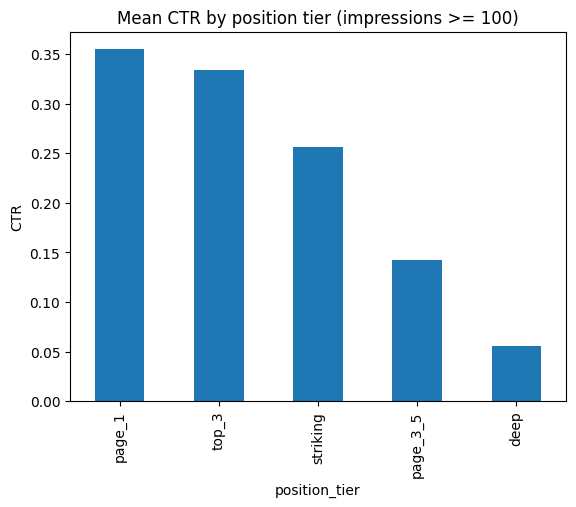

In [5]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [6]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

### Discovery A - but for all impressions (impressions_90d > 0)

In [7]:
# Discovery A -but for all impressions 
# (impressions > 0 yields all because all these columns are >= 1)

all_impressions = df[df['impressions_90d'] > 0]
corr = all_impressions['search_volume'].corr(all_impressions['impressions_90d'])
print(f"Correlation between search_volume and impressions_90d (impressions > 0): {corr:.3f}")

Correlation between search_volume and impressions_90d (impressions > 0): 0.001


### Discovery B - finding worst content_type by CTR at the same position_tier

content_type,feedly article,keyword article
count,3.000000,5.000000
mean,7.998192,0.219906
std,8.908873,0.301948
min,1.646091,0.000000
25%,2.906379,0.000000
50%,4.166667,0.000000
75%,11.174242,0.518135
max,18.181818,0.581395


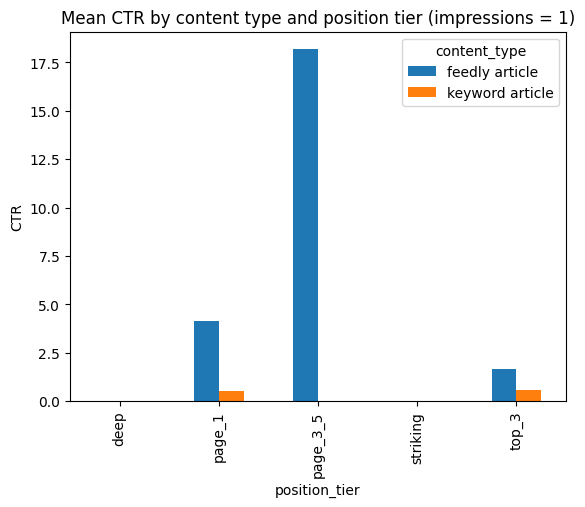

In [8]:
# Discovery B - finding worst content_type by CTR at the same position_tier

# the worst one is the one with the least of the impressions,
# and the least of impressions as per the data-dictionary.md is 1

least_impressions = df[df['impressions_90d'] <= 1]
ctr_by_type_and_tier = least_impressions\
    .groupby(["content_type", "position_tier"])["ctr"]\
    .mean()\
    .sort_values(ascending=True)\
    .unstack(level=0)

ctr_by_type_and_tier.plot(kind="bar", title="Mean CTR by content type and position tier (impressions = 1)", ylabel="CTR")
ctr_by_type_and_tier.describe()

**Findings:** As per the methods deployed by me, and findings based on the methods, in the provided dataset, the evidence at the hand proves that the worst `content_type` is ***keyword article*** as per the `ctr` throughout every `position_tier`

### Running discoveries

#### `content_age_days` and `trend_direction` relation

trend_direction
stable    295.439953
up        288.478806
flat      245.889757
new       238.718247
down      236.178637
Name: content_age_days, dtype: float64

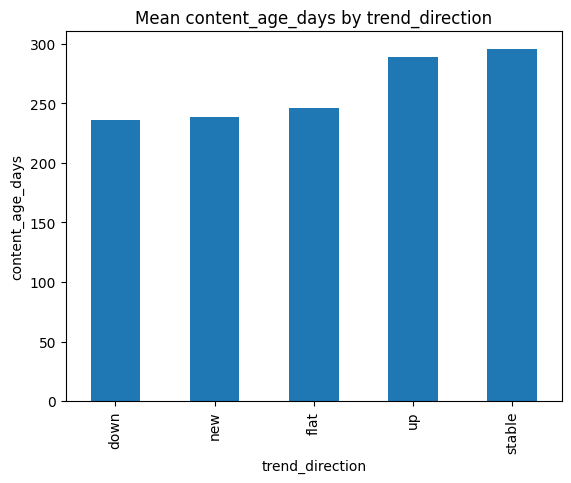

In [9]:
# whether content_age_days relates to trend_direction?

# method 1 - grouping by trend_direction and taking only content_age_days
content_days_by_trend_dir = df.groupby(by="trend_direction")['content_age_days']
content_days_by_trend_dir\
    .mean()\
    .sort_values(ascending=True)\
    .plot(
        kind="bar",
        title="Mean content_age_days by trend_direction",
        ylabel="content_age_days"
    )
content_days_by_trend_dir\
    .mean()\
    .sort_values(ascending=False)

In [10]:
# method 2 - grouping by trend_direction and taking all numeric columns, then sorting by content_age_days

import plotly.express as px

# Plotly automatically treats string indices as separate categories, so I went for this library
numeric_columns = [
    column for column in df.columns
    if np.issubdtype(df[column].dtype, np.number)
]
print("Numeric columns:", numeric_columns)
by_trend = df.groupby(by="trend_direction")[numeric_columns].median().sort_values(by="content_age_days", ascending=True)
fig = px.bar(by_trend, x=by_trend.index, y='content_age_days', color=by_trend.index, title="Median content_age_days by trend_direction (bar plot)")
fig.show()
by_trend

Numeric columns: ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct']


,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
trend_direction,,,,,,,,,,,,,,,,,,,,,
down,10.0,0.0,0.0,2909.0,19278.0,961.0,1.0,9.0,8.0,8.0,...,2.0,216.0,5.0,20.0,0.08,11.3,0.0,5.77,0.0,-55.60
flat,10.0,0.0,0.0,2698.5,17610.0,4.0,0.0,2.0,2.0,2.0,...,1.0,231.0,5.0,20.0,0.00,6.6,0.0,0.00,0.0,NaN
new,10.0,0.0,0.0,2239.0,14746.5,3.0,0.0,2.0,2.0,2.0,...,0.0,279.0,5.0,20.0,0.00,0.0,0.0,20.83,0.0,NaN
up,10.0,0.0,0.0,2847.5,19097.5,587.0,1.0,7.0,7.0,7.0,...,2.0,291.5,5.0,22.0,0.09,15.3,0.0,3.57,0.0,62.55
stable,10.0,0.0,0.0,2912.5,19308.0,1944.5,3.0,19.0,17.0,16.0,...,4.0,300.0,5.0,22.0,0.17,11.4,0.0,4.03,0.0,-3.80


**Finding:** As per the both methods deployed me, which yielded the evidences and patterns to reveal the conventional assumption of linear content decay being incorrect here. 

The data exhibits a distinct survival bias. Older pages (~295 days) dominate the `stable` and `up` cohorts, while younger mid-life content (~236 days) is significantly more susceptible to active performance drops `(trend_direction == "down")`. Additionally, the `new` classification indicates newly initialized analytics tracking on established pages rather than fresh publication dates.

#### `avg_position` and `ctr` relation

In [11]:
# whether avg_position relates to ctr?

float(df['avg_position'].corr(df['ctr']))

-0.0725902997683247

**Findings:** This clearly indicates that there's no correlation `avg_position` and `ctr` as per the correlation coefficient value of `-0.0725902997683247` which is lower than zero, indicating no correlation between these two variables.